In [1]:
import pandas as pd
import numpy as np
import os, re, glob 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker
from itertools import combinations
from scipy.spatial.distance import pdist, squareform
from skbio.diversity import beta_diversity
from skbio.stats.distance import permanova
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from statannotations.Annotator import Annotator
from scipy.stats import kruskal

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

adf=pd.read_csv("panres_annotations.tsv",sep="\t")
ndf=pd.DataFrame(adf.groupby('gene')['value'].agg(list)).reset_index()
dd=dict(zip(ndf["gene"], ndf["value"]))

ndf = pd.read_csv('https://zenodo.org/records/8055116/files/PanRes_data_v1.0.0.tsv', sep='\t', skiprows=1)

adf["gene"]=adf["gene"].str.replace("_v1.0.1", "")
ndf["userGeneName"]=ndf["userGeneName"].str.replace("_v1.0.0", "")

In [2]:
length_dict=dict(zip(ndf['userGeneName'], ndf['gene_len']))

https://www.nature.com/articles/s41467-022-34312-7?fromPaywallRec=false#Sec10
https://archimer.ifremer.fr/doc/00989/110109/123905.pdf

In [3]:
MT=[]
for f in glob.glob("res/*"):
    df=pd.read_csv(f,sep="\t")
    df["sample"]=re.sub("cleaned.tsv", "", re.sub("res/", "",f))
    MT.append(df)

MT=pd.concat(MT)
MT=MT[(MT["Template_Coverage"]>=70)  & (MT["Template_Identity"]>=70) & (MT["Query_Identity"]>=90)  & (MT["Query_Coverage"]>=70) & (MT["p_value"]<=1e-10)]
MT["AMR"]=MT["#Template"].map(dd)

In [4]:
MT["aminoglycoside"]=MT["AMR"].astype(str).str.contains("glycoside")
MT["beta_lactam"]=MT["AMR"].astype(str).str.contains("lactam")
MT["fluoroquinolone"]=MT["AMR"].astype(str).str.contains("fluoroqu")
MT["fosfomycin"]=MT["AMR"].astype(str).str.contains("mycin")
MT["glycopeptide"]=MT["AMR"].astype(str).str.contains("glycop")

MT["lincosamide"]=MT["AMR"].astype(str).str.contains("samide")
MT["macrolide"]=MT["AMR"].astype(str).str.contains("macrolide")
MT["nitroimidazole"]=MT["AMR"].astype(str).str.contains("midazole")
MT["oxazolidinone"]=MT["AMR"].astype(str).str.contains("oxazol")
MT["phenicol"]=MT["AMR"].astype(str).str.contains("phenicol")

MT["pleuromutilin"]=MT["AMR"].astype(str).str.contains("mutilin")
MT["polymyxin"]=MT["AMR"].astype(str).str.contains("myxin")
MT["pseudomonic_acid"]=MT["AMR"].astype(str).str.contains("pseudomonic")
MT["quinolone"]=MT["AMR"].astype(str).str.contains("quinolone")
MT["rifampicin"]=MT["AMR"].astype(str).str.contains("rifampicin")

MT["streptogramin_a"]=MT["AMR"].astype(str).str.contains("streptogramin_a")
MT["streptogramin_b"]=MT["AMR"].astype(str).str.contains("streptogramin_b")
MT["tetracycline"]=MT["AMR"].astype(str).str.contains("tetracyc")
MT["sulfonamides"]=MT["AMR"].astype(str).str.contains("sulfonamid")
MT["folate_pathway_antagonist"]=MT["AMR"].astype(str).str.contains("folate")
MT["peptide"]=MT["AMR"].astype(str).str.contains("peptide")
MT["streptothricin"]=MT["AMR"].astype(str).str.contains("streptothricin")


MT["mercury_resistance"]=MT["AMR"].astype(str).str.contains("mercury")
MT["metalres"]=MT["AMR"].astype(str).str.contains("metalres")
MT["drug_and_biocide_smr_efflux_pumps"]=MT["AMR"].astype(str).str.contains("drug_and_biocide_smr_efflux_pumps")
MT["drug_and_biocide_resistance"]=MT["AMR"].astype(str).str.contains("drug_and_biocide_resistance")
MT["drug_and_biocide_and_metal_resistance"]=MT["AMR"].astype(str).str.contains("drug_and_biocide_and_metal_resistance")


cols=list(MT.columns)[13:]
for c in cols:
    MT[c] = MT[c].where(~MT[c], c)

MT['Class'] = MT[cols].replace(False, pd.NA).bfill(axis=1).iloc[:, 0]



In [5]:
MT["Class"].unique()

array(['beta_lactam', 'sulfonamides', 'macrolide', 'rifampicin',
       'fluoroquinolone', 'phenicol', 'aminoglycoside', 'lincosamide',
       'tetracycline', 'folate_pathway_antagonist', 'fosfomycin',
       'mercury_resistance', 'metalres',
       'drug_and_biocide_smr_efflux_pumps', 'polymyxin', 'streptothricin',
       'peptide', 'drug_and_biocide_and_metal_resistance', <NA>,
       'nitroimidazole', 'drug_and_biocide_resistance', 'quinolone',
       'glycopeptide'], dtype=object)

In [6]:
MT["#Template"]=MT["#Template"].str.replace("_v1.0.1", "")
MT["sample"]=MT["sample"].str.replace("AACMFLCHV1", "")
MT=MT[~MT["Class"].isna()]

In [9]:
MT=MT[~MT["Class"].isin(["mercury_resistance", "metalres", "drug_and_biocide_smr_efflux_pumps",
                    "drug_and_biocide_resistance", "drug_and_biocide_and_metal_resistance"])]

In [12]:
MT["canals"]=[x[0:3] if "CW" not in x else x[0:2] for x in MT["sample"]]
MT["canals"]=MT["canals"].str.replace("MBM", "MBD").str.replace("MBU", "MBD")

In [13]:
countdf = (MT.groupby('sample')['#Template'].nunique().reset_index(name='n'))
countdf=countdf.sort_values("n", ascending=False)
countdf["canal"]=[x[0:3] if "CW" not in x else x[0:2] for x in countdf["sample"]]
countdf["canal"]=countdf["canal"].str.replace("MBM", "MBD").str.replace("MBU", "MBD")

In [103]:
top_templates = (MT.groupby('#Template')['sample'].nunique().sort_values(ascending=False).head(20).reset_index(name='n_samples'))
top_templates

,#Template,n_samples
0,pan_8395,33
1,pan_11249,31
2,pan_7501,30
3,pan_10634,28
4,pan_11495,26
...,...,...
215,pan_10687,1
216,pan_10700,1
217,pan_10704,1
218,pan_10706,1


In [105]:
len(top_templates[top_templates["n_samples"]>=16])

15

In [18]:
MT[MT["#Template"].isin(top_templates["#Template"].to_list())].to_csv("Top_hits.csv")

In [19]:
MT[MT["#Template"].isin(["pan_2232"])][0:5]

,#Template,Score,Expected,Template_length,Template_Identity,Template_Coverage,Query_Identity,Query_Coverage,Depth,q_value,p_value,sample,AMR,aminoglycoside,beta_lactam,fluoroquinolone,fosfomycin,glycopeptide,lincosamide,macrolide,nitroimidazole,oxazolidinone,phenicol,pleuromutilin,polymyxin,pseudomonic_acid,quinolone,rifampicin,streptogramin_a,streptogramin_b,tetracycline,sulfonamides,folate_pathway_antagonist,peptide,streptothricin,mercury_resistance,metalres,drug_and_biocide_smr_efflux_pumps,drug_and_biocide_resistance,drug_and_biocide_and_metal_resistance,Class,canals
53,pan_2232,40800,155,837,100.00,100.00,100.00,100.00,49.56,40335.25,1.000000e-26,CW2A,"[amrfinderplus|446403113|wp_000480968.1|ng_047464.1|1|1|aph(6)-id|aph(6)-id|aminoglycoside_o-phosphotransferase_aph(6)-id, argannot|(agly)strb|fj474091:264-1100, megares|meg_1086|drugs|aminoglycosides|aminoglycoside_o-phosphotransferases|aph6, resfinder|aph(6)-id_1_m28829, amrfinderplus, argannot, megares, resfinder, 837, antimicrobial, aminoglycoside, pan_4007_v1.0.1]",aminoglycoside,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,aminoglycoside,CW
13,pan_2232,7282,155,837,76.22,76.22,100.00,131.19,8.71,6827.14,1.000000e-26,AJBDWS2C,"[amrfinderplus|446403113|wp_000480968.1|ng_047464.1|1|1|aph(6)-id|aph(6)-id|aminoglycoside_o-phosphotransferase_aph(6)-id, argannot|(agly)strb|fj474091:264-1100, megares|meg_1086|drugs|aminoglycosides|aminoglycoside_o-phosphotransferases|aph6, resfinder|aph(6)-id_1_m28829, amrfinderplus, argannot, megares, resfinder, 837, antimicrobial, aminoglycoside, pan_4007_v1.0.1]",aminoglycoside,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,aminoglycoside,AJB
15,pan_2232,22357,477,837,99.88,100.00,99.88,100.00,26.87,20965.72,1.000000e-26,EXPMDS1B,"[amrfinderplus|446403113|wp_000480968.1|ng_047464.1|1|1|aph(6)-id|aph(6)-id|aminoglycoside_o-phosphotransferase_aph(6)-id, argannot|(agly)strb|fj474091:264-1100, megares|meg_1086|drugs|aminoglycosides|aminoglycoside_o-phosphotransferases|aph6, resfinder|aph(6)-id_1_m28829, amrfinderplus, argannot, megares, resfinder, 837, antimicrobial, aminoglycoside, pan_4007_v1.0.1]",aminoglycoside,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,aminoglycoside,EXP
100,pan_2232,224436,729,837,99.88,100.00,99.88,100.00,271.37,222255.98,1.000000e-26,AJA1A,"[amrfinderplus|446403113|wp_000480968.1|ng_047464.1|1|1|aph(6)-id|aph(6)-id|aminoglycoside_o-phosphotransferase_aph(6)-id, argannot|(agly)strb|fj474091:264-1100, megares|meg_1086|drugs|aminoglycosides|aminoglycoside_o-phosphotransferases|aph6, resfinder|aph(6)-id_1_m28829, amrfinderplus, argannot, megares, resfinder, 837, antimicrobial, aminoglycoside, pan_4007_v1.0.1]",aminoglycoside,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,aminoglycoside,AJA
27,pan_2232,8808,106,837,94.27,94.27,100.00,106.08,10.58,8494.18,1.000000e-26,EXPUPS3A,"[amrfinderplus|446403113|wp_000480968.1|ng_047464.1|1|1|aph(6)-id|aph(6)-id|aminoglycoside_o-phosphotransferase_aph(6)-id, argannot|(agly)strb|fj474091:264-1100, megares|meg_1086|drugs|aminoglycosides|aminoglycoside_o-phosphotransferases|aph6, resfinder|aph(6)-id_1_m28829, amrfinderplus, argannot, megares, resfinder, 837, antimicrobial, aminoglycoside, pan_4007_v1.0.1]",aminoglycoside,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,aminoglycoside,EXP


In [20]:
ARGdf=pd.read_csv("top_hits_canonical.csv")

In [21]:
ARGdf=ARGdf[~ARGdf["Interpretation"].isna()]

In [22]:
hierso=ARGdf.copy()

In [23]:
ARGdf=ARGdf[ARGdf["n_samples"]>=10]

In [24]:
rn={'aph(6)-id':'strB', 'aph(3'')-ib': 'strA', 'sulI': 'sul1'}
ARGdf["Interpretation"]=[rn[x] if x in rn.keys() else x for x in ARGdf["Interpretation"]]

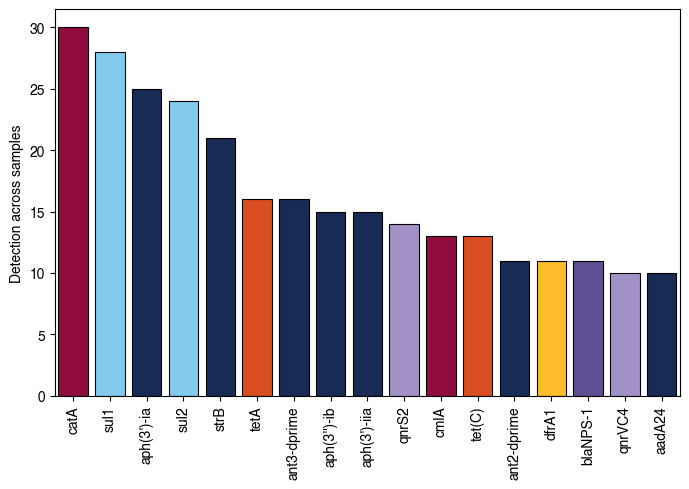

In [101]:

col_dict = {
    'Aminoglycoside': '#182b55',
    'Beta Lactam': '#5f4e94','Fluoroquinolone': '#a291c7',
    'Phenicol': '#900c3f', 'Sulfonamides': '#82cbec',
    'Tetracycline': '#d94f21',
    'Folate pathway antagonist': '#febd2b',
    'Fosfomycin': '#9aab4b',
    'Macrolide': '#2072AF', 'Polymyxin': '#8AB9F1','Rifampicin': '#29AB87',
    'Lincosamide': '#81D8D0','Quinolone': '#FF4F00','Nitroimidazole': '#FFA500',
    'Peptide': '#960018', 'Glycopeptide': '#BEBFC5', 'Streptothricin': '#536878'
}

plot_df = (ARGdf.sort_values("n_samples", ascending=False).drop_duplicates(subset="Interpretation", keep="first").sort_values("n_samples", ascending=False).copy())
bar_colors = plot_df["Class"].map(col_dict).fillna("#BDBDBD")

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(plot_df["Interpretation"], plot_df["n_samples"], color=bar_colors, edgecolor="black", linewidth=0.8)

ax.set_xlabel("")
ax.set_ylabel("Detection across samples")
ax.tick_params(axis="x", labelrotation=90)
ax.set_xlim(-0.5, len(plot_df) - 0.5)

present_classes = [ cls for cls in col_dict if cls in plot_df["Class"].dropna().unique()]

plt.tight_layout()

plt.show()

In [29]:
#len(top_templates[top_templates["n_samples"]>=18])

In [30]:
kyk=ndf[~ndf["fa_descript"].isna()] 

In [32]:
MT[MT["#Template"].isin(mcr)]

,#Template,Score,Expected,Template_length,Template_Identity,Template_Coverage,Query_Identity,Query_Coverage,Depth,q_value,p_value,sample,AMR,aminoglycoside,beta_lactam,fluoroquinolone,fosfomycin,glycopeptide,lincosamide,macrolide,nitroimidazole,oxazolidinone,phenicol,pleuromutilin,polymyxin,pseudomonic_acid,quinolone,rifampicin,streptogramin_a,streptogramin_b,tetracycline,sulfonamides,folate_pathway_antagonist,peptide,streptothricin,mercury_resistance,metalres,drug_and_biocide_smr_efflux_pumps,drug_and_biocide_resistance,drug_and_biocide_and_metal_resistance,Class,canals
46,pan_580,12074,1460,1644,96.78,97.51,99.25,102.56,7.48,8321.95,1.000000e-26,AJA1A,"[amrfinderplus|927580504|wp_053821788.1|ng_055658.1|1|1|mcr-5.1|mcr-5|phosphoethanolamine--lipid_a_transferase_mcr-5.1, argannot|(col)mcr-5.1|mg241339:1-1644, card_amr|gb|ky807920.1|-|9895-11539|aro:3004332|mcr-5.1, megares|meg_3705|drugs|lipopeptides|colistin_phosphoethanolamine_transferase|mcr, resfinder|mcr-5.1_1_ky807921, amrfinderplus, argannot, card_amr, megares, resfinder, 1644, antimicrobial, polymyxin, pan_580_v1.0.1]",False,False,False,False,False,False,False,False,False,False,False,polymyxin,False,False,False,False,False,False,False,False,peptide,False,False,False,False,False,False,polymyxin,AJA
64,pan_1029,11631,1444,1626,84.75,85.92,98.64,116.39,7.24,7934.74,1.000000e-26,AJA1A,"[amrfinderplus|499958169|wp_011638903.1|ng_057461.1|1|1|mcr-4.3|mcr-4|phosphoethanolamine--lipid_a_transferase_mcr-4.3, argannot|(col)mcr-4.3|ng_057461:1-1626, card_amr|gb|mg026621.1|+|0-1626|aro:3004695|mcr-4.3, megares|meg_3720|drugs|lipopeptides|colistin_phosphoethanolamine_transferase|mcr, resfinder|mcr-4.3_1_mg026621, amrfinderplus, argannot, card_amr, megares, resfinder, 1626, antimicrobial, polymyxin, pan_1017_v1.0.1]",False,False,False,False,False,False,False,False,False,False,False,polymyxin,False,False,False,False,False,False,False,False,peptide,False,False,False,False,False,False,polymyxin,AJA
101,pan_2256,19904,1443,1626,79.58,79.64,99.92,125.56,12.37,15962.83,1.000000e-26,AJA1A,"[amrfinderplus|1231368033|wp_094312656.1|ng_065453.1|1|1|mcr-3.21|mcr-3|phosphoethanolamine--lipid_a_transferase_mcr-3.21, argannot|(col)mcr-3.21|ng_060582:101-1726, megares|meg_3684|drugs|lipopeptides|colistin_phosphoethanolamine_transferase|mcr, resfinder|mcr-3.21_1_ng060582, amrfinderplus, argannot, megares, resfinder, 1626, antimicrobial, polymyxin, pan_11153_v1.0.1]",False,False,False,False,False,False,False,False,False,False,False,polymyxin,False,False,False,False,False,False,False,False,peptide,False,False,False,False,False,False,polymyxin,AJA
26,pan_580,14108,2690,1644,92.15,92.21,99.93,108.44,8.61,7760.79,1.000000e-26,MBMDS1B,"[amrfinderplus|927580504|wp_053821788.1|ng_055658.1|1|1|mcr-5.1|mcr-5|phosphoethanolamine--lipid_a_transferase_mcr-5.1, argannot|(col)mcr-5.1|mg241339:1-1644, card_amr|gb|ky807920.1|-|9895-11539|aro:3004332|mcr-5.1, megares|meg_3705|drugs|lipopeptides|colistin_phosphoethanolamine_transferase|mcr, resfinder|mcr-5.1_1_ky807921, amrfinderplus, argannot, card_amr, megares, resfinder, 1644, antimicrobial, polymyxin, pan_580_v1.0.1]",False,False,False,False,False,False,False,False,False,False,False,polymyxin,False,False,False,False,False,False,False,False,peptide,False,False,False,False,False,False,polymyxin,MBD


In [35]:
ui=list(set(MT["#Template"].to_list()))
ui=[re.sub("_v1.0.1", "_v1.0.0", x) for x in ui]

In [36]:
canondf=ndf[(ndf["userGeneName"].isin(ui))& (~ndf["fa_descript"].isna()) & (ndf["fa_descript"].str.contains("\("))]
canonical=list(canondf["userGeneName"].unique())
canonical=[re.sub("_v1.0.0", "_v1.0.1", x) for x in canonical]

In [37]:
amr_dict=dict(zip(canondf["userGeneName"], canondf["fa_descript"]))

In [38]:
r=[]
for c in canonical:
    subdf=MT[MT["#Template"]==c]
    r.append({"id":c, "sample#":len(subdf["sample"].unique()), "name":amr_dict[c]})

cdf=pd.DataFrame(r)

In [39]:
cdf.sort_values("sample#", ascending=False)

,id,sample#,name
0,pan_19,24,(Sul)sul2
76,pan_692,24,(AGly)aph(3'')-Ia
44,pan_2232,21,(AGly)strB
62,pan_6296,16,(Tet)tetA
28,pan_1365,14,(Flq)qnrS2
...,...,...,...
26,pan_741,1,(Bla)blaOXA-101
24,pan_1839,1,(Bla)blaOXA-796
23,pan_11,1,(Bla)blaOXA-1
57,pan_859,1,(Tet)tetL


In [40]:
cdf2=cdf.copy()
cdf2["name"]=cdf2["name"].str.lower()

In [41]:
pat="aad"
print(cdf2[cdf2["name"].str.contains(pat)].sort_values("sample#", ascending=False))
print(hierso[hierso["Interpretation"].str.lower().str.contains(pat)])

          id  sample#            name
65  pan_4237       10    (agly)aada24
63   pan_522        7     (agly)aada5
66  pan_7105        6  (agly)aada1-pm
34  pan_1621        3      (agly)aads
46   pan_249        1      (agly)aadb
64   pan_508        1    (agly)aada10
   #Template   PanRes_cluster  n_samples  max_score           Class  \
30  pan_4237  pan_6401_v1.0.1         10      34430  Aminoglycoside   
46  pan_7105  pan_6401_v1.0.1          6     110614  Aminoglycoside   
84  pan_1621  pan_1621_v1.0.1          3      21838  Aminoglycoside   

   canonical_call Interpretation                gene_or_family  \
30      canonical         aadA24           aada24, ant3-dprime   
46      canonical          aadA1  aada1, aada1-pm, ant3-dprime   
84      canonical           aads                    aads, ant6   

                                       sources  \
30                argannot, megares, resfinder   
46                           argannot, megares   
84  amrfinderplus, argannot, card_

In [42]:
rdf=pd.read_csv("total_reads.txt", header=None, sep="\t")
rdf=rdf[rdf[1]=="R1.fastq.gz"]
rdf["map"]=rdf[0].str.replace("_", "")

perc=[]
for f in glob.glob("*.mapstat"):
    if "NE" not in f and  "NTC" not in f: 
        df = pd.read_csv(f, sep="\t", skiprows=6)
        n=re.sub("AACMFLCHV1cleaned.mapstat", "", f)
        t=rdf[rdf["map"]==n][2].values[0]
        s=(df["readCount"].sum()/t)*100
        
        perc.append(s)

print(np.min(perc))
print(np.max(perc))
print(np.median(perc))

0.01674260253355168
1.8046162643247887
0.205285054489519


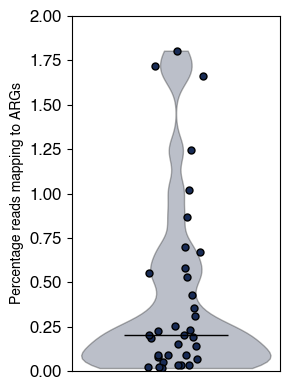

In [43]:
plot_df = pd.DataFrame({"category": ["ARGs"] * len(perc), "percent_ARG_reads": perc})

fig, ax = plt.subplots(figsize=(3, 4))

sns.violinplot(data=plot_df,x="category",y="percent_ARG_reads",inner=None,cut=0,scale="width",bw_adjust=0.3,color="#182b55",linewidth=1,alpha=1,ax=ax)

for violin in ax.collections:
    violin.set_alpha(0.3)
    violin.set_edgecolor("black")
    violin.set_linewidth(1)

sns.stripplot(data=plot_df, x="category",y="percent_ARG_reads",color="#182b55", size=5,jitter=0.12,alpha=1,edgecolor="black",linewidth=1,ax=ax)
median = plot_df["percent_ARG_reads"].median()

ax.hlines( y=median,xmin=-0.22,xmax=0.22,color="black",linewidth=1,zorder=5)
ax.set_ylim(0, 2)

ax.set_xlabel("")
ax.set_ylabel("Percentage reads mapping to ARGs")
plt.xticks(size=12)
plt.yticks(size=12)
ax.set_xticks([])
ax.set_xticklabels([])

plt.tight_layout()

plt.show()

In [45]:
counts = MT.groupby(['sample', 'Class']).size().unstack(fill_value=0)

In [46]:
rn=dict(zip(list(MT["Class"].unique()), [re.sub("lactam", "Lactam", re.sub("_", " ", x.capitalize())) for x in list(MT["Class"].unique())]))

In [47]:
MT["Class"]=MT["Class"].map(rn)

In [48]:
MT["Class"].unique()

<ArrowStringArray>
[              'Beta Lactam',              'Sulfonamides',
                 'Macrolide',                'Rifampicin',
           'Fluoroquinolone',                  'Phenicol',
            'Aminoglycoside',               'Lincosamide',
              'Tetracycline', 'Folate pathway antagonist',
                'Fosfomycin',                 'Polymyxin',
            'Streptothricin',                   'Peptide',
            'Nitroimidazole',                 'Quinolone',
              'Glycopeptide']
Length: 17, dtype: str

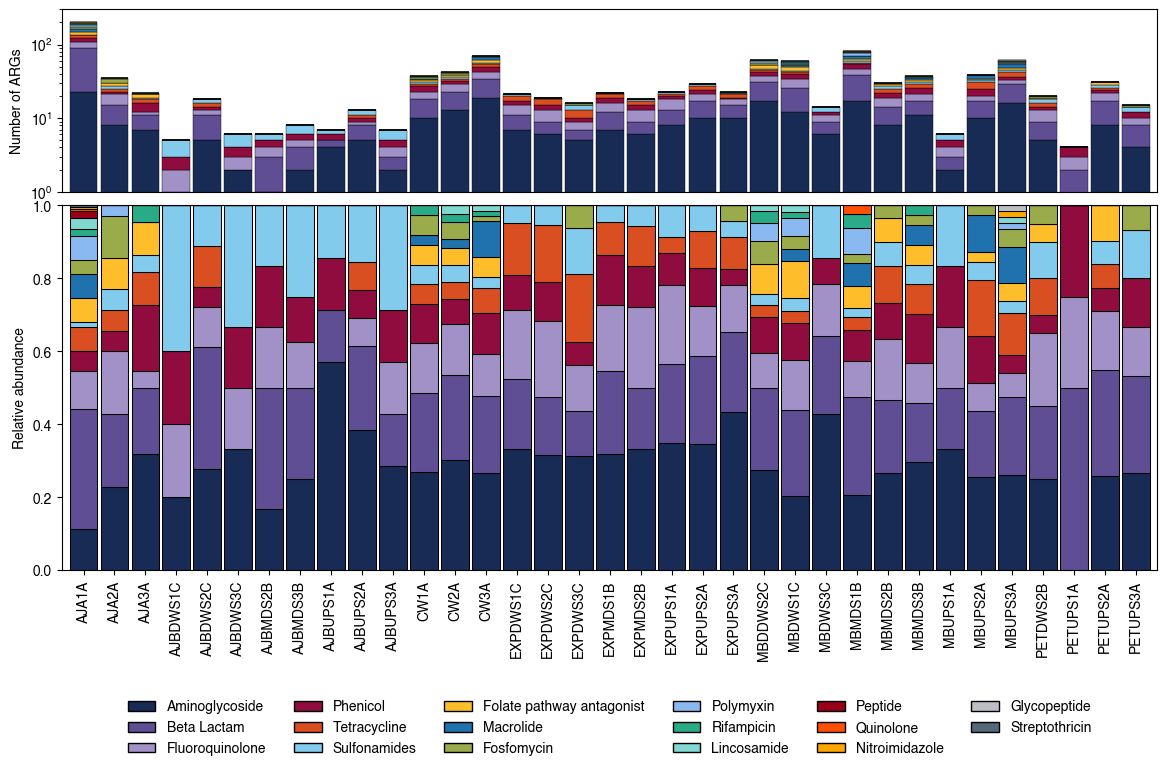

In [49]:
counts = (MT.groupby(["sample", "Class"]).size().unstack(fill_value=0))
counts = counts.loc[counts.sum(axis=1) > 0]
counts = counts[[c for c in counts.columns if c in col_dict]]
class_order = (counts.sum(axis=0).sort_values(ascending=False).index.tolist())
counts = counts[class_order]
rel = counts.div(counts.sum(axis=1), axis=0).fillna(0)
colors = [col_dict[c] for c in class_order]


fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 2]}
)

counts.plot(kind="bar",stacked=True,ax=ax_top,color=colors,legend=False,edgecolor="black",linewidth=0.3,width=0.9)

ax_top.set_ylabel("Number of ARGs")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
ax_top.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
ax_top.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs="auto", numticks=100))
ax_top.yaxis.set_minor_formatter(mticker.NullFormatter())

ymax = counts.sum(axis=1).max()
ax_top.set_ylim(1, ymax * 1.5)

rel.plot(kind="bar",stacked=True,ax=ax_bot,color=colors,legend=False,edgecolor="black",linewidth=0.75, width=0.9)

ax_bot.set_ylabel("Relative abundance")
ax_bot.set_xlabel("")
ax_bot.set_ylim(0, 1)

ax_bot.set_xticklabels(ax_bot.get_xticklabels(), rotation=90)

handles = [
    plt.Rectangle(
        (0, 0), 1, 1,
        facecolor=col_dict[label],
        edgecolor="black",
        linewidth=1
    )
    for label in class_order
]

ncol = math.ceil(len(class_order) / 3)

ax_bot.legend(
    handles,
    class_order,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.32),
    ncol=ncol,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05, bottom=0.28)

plt.show()

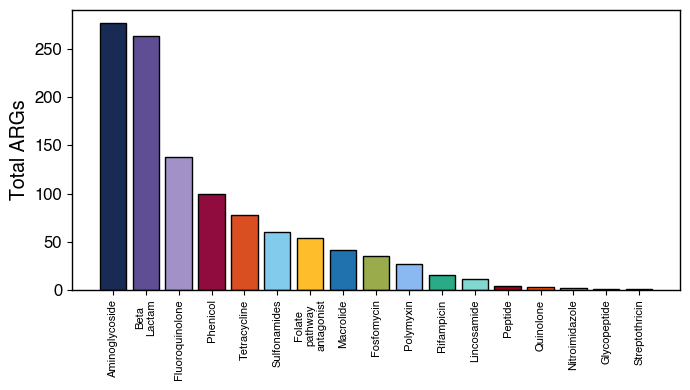

In [50]:
counts_long = (counts.sum(numeric_only=True).reset_index())

counts_long.columns = ["name", "value"]
plot_df = counts_long.sort_values("value", ascending=False).copy()
bar_cols = plot_df["name"].map(col_dict).fillna("#BEBFC5")

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(plot_df["name"],plot_df["value"],color=bar_cols,edgecolor="black",linewidth=1)

ax.set_xlabel("")
for label in ax.get_xticklabels():
    label.set_ha("right")

# for spine in ax.spines.values():
#     spine.set_color("black")
#     spine.set_linewidth(1)

ax.grid(False)

ax.set_xticklabels([label.get_text().replace(" ", "\n")
    for label in ax.get_xticklabels()])
ax.tick_params(axis="x", labelrotation=90, labelsize=8, colors="black")
ax.tick_params(axis="y", labelsize=12, colors="black")

for label in ax.get_xticklabels():
    label.set_ha("center")

ax.set_ylabel("Total ARGs", fontsize=14)
plt.tight_layout()

plt.show()

In [51]:
rel = rel.apply(pd.to_numeric, errors="coerce").fillna(0)
rel = rel.loc[:, rel.sum(axis=0) > 0]
bc_dist = pdist(rel.values, metric="braycurtis")
bc_df = pd.DataFrame(squareform(bc_dist),index=rel.index.astype(str),columns=rel.index.astype(str))
mask = np.triu(np.ones(bc_df.shape), k=1).astype(bool)
pairwise_s= (bc_df.where(mask).stack().rename("bray_curtis"))
pairwise_bc = pd.DataFrame({ "sample1": pairwise_s.index.get_level_values(0),"sample2": pairwise_s.index.get_level_values(1),"bray_curtis": pairwise_s.values})
pairwise_bc = pairwise_bc.sort_values("bray_curtis", ascending=False)

pairwise_bc

,sample1,sample2,bray_curtis
312,AJBUPS1A,PETUPS1A,0.714286
5,AJA1A,AJBDWS3C,0.711443
3,AJA1A,AJBDWS1C,0.711443
592,EXPDWS3C,PETUPS1A,0.687500
8,AJA1A,AJBUPS1A,0.673063
...,...,...,...
1220,PETUPS3A,MBUPS3A,NaN
1221,PETUPS3A,PETDWS2B,NaN
1222,PETUPS3A,PETUPS1A,NaN
1223,PETUPS3A,PETUPS2A,NaN


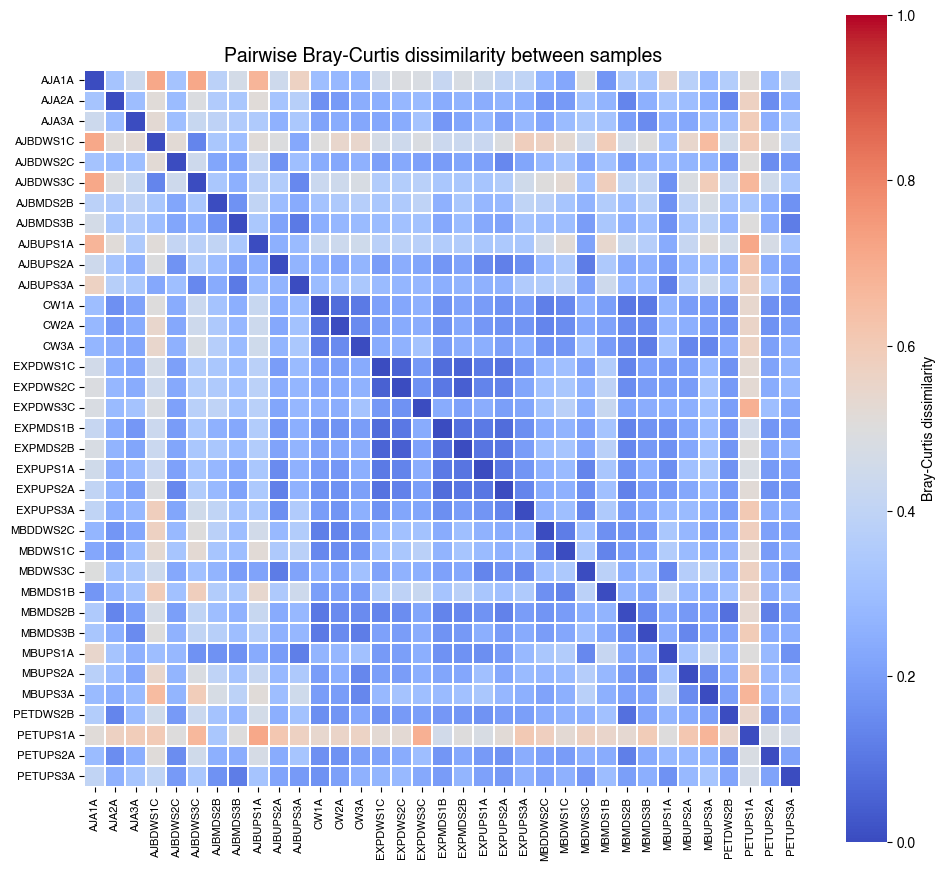

In [52]:
fig, ax = plt.subplots(figsize=(10, 9))

sns.heatmap( bc_df, cmap="coolwarm", square=True, linewidths=0.2,  vmin=0, vmax=1, linecolor="white", cbar_kws={"label": "Bray-Curtis dissimilarity"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Pairwise Bray-Curtis dissimilarity between samples", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

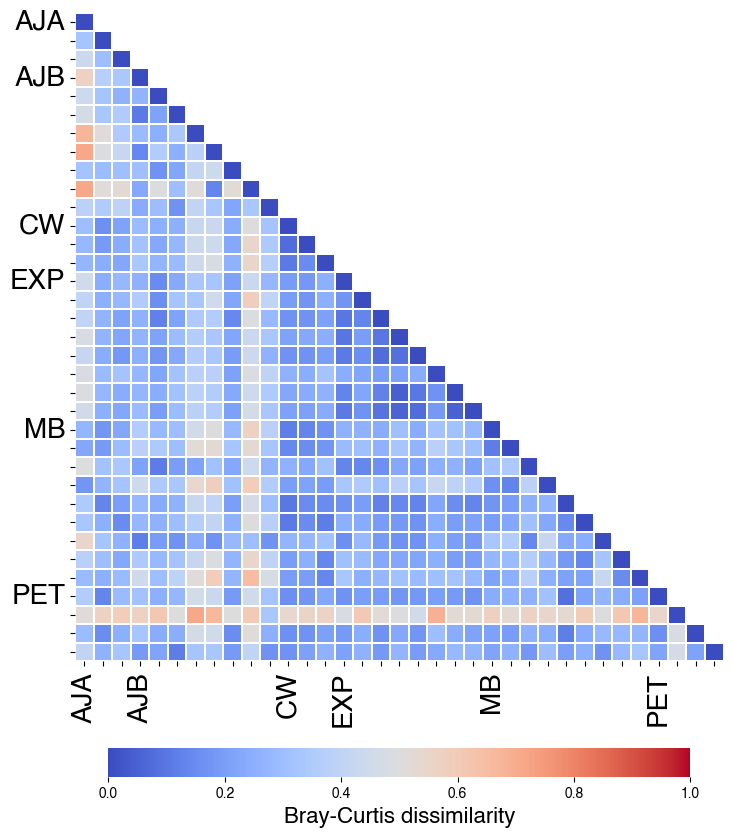

In [53]:
metadata = pd.DataFrame(index=bc_df.index)

metadata["canal"] = np.select([metadata.index.str.contains("AJA", case=False, regex=False), metadata.index.str.contains("AJB", case=False, regex=False),  metadata.index.str.contains("CW", case=False, regex=False), metadata.index.str.contains("MB", case=False, regex=False), metadata.index.str.contains("PET", case=False, regex=False), metadata.index.str.contains("EXP", case=False, regex=False), ],  ["AJA", "AJB","CW", "MB", "PET", "EXP" ], default=np.nan)
canal_order = ["AJA", "AJB", "CW", "EXP", "MB", "PET"]

metadata["canal"] = pd.Categorical( metadata["canal"],categories=canal_order,ordered=True)
metadata = metadata.sort_values("canal")
bc_sorted = bc_df.loc[metadata.index, metadata.index]
canal_labels = metadata["canal"].astype(str).values

tick_labels = []
previous = None

for canal in canal_labels:
    if canal != previous:
        tick_labels.append(canal)
    else:
        tick_labels.append("")
    previous = canal


mask = np.triu(np.ones_like(bc_sorted, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 9))

sns.heatmap(  bc_sorted, mask=mask,cmap="coolwarm",square=True,linewidths=0.2,vmin=0,vmax=1,linecolor="white",cbar_kws={ "label": "Bray-Curtis dissimilarity","orientation": "horizontal", "pad": 0.1, "shrink": 0.6,},ax=ax)
cbar = ax.collections[0].colorbar

cbar.ax.tick_params(labelsize=10)
cbar.ax.xaxis.label.set_size(16)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("", fontsize=14)

ax.set_xticklabels(tick_labels, rotation=90, fontsize=20)
ax.set_yticklabels(tick_labels, rotation=0, fontsize=20)

plt.tight_layout()

plt.show()

In [54]:
rel2 = rel.copy()
rel2 = rel2.apply(pd.to_numeric, errors="coerce").fillna(0)
rel2 = rel2.loc[:, rel2.sum(axis=0) > 0]

In [55]:
metadata["canal"] = np.select([metadata.index.str.contains("AJA", case=False, regex=False),metadata.index.str.contains("AJB", case=False, regex=False),metadata.index.str.contains("CW", case=False, regex=False),metadata.index.str.contains("MB", case=False, regex=False),metadata.index.str.contains("PET", case=False, regex=False), metadata.index.str.contains("EXP", case=False, regex=False), ], ["AJA", "AJB", "CW", "MB", "PET", "EXP"],default=np.nan)
metadata = metadata.dropna(subset=["canal"])
rel2 = rel2.loc[metadata.index]
valid_canals = metadata["canal"].value_counts()
valid_canals = valid_canals[valid_canals >= 2].index
metadata = metadata[metadata["canal"].isin(valid_canals)]
rel2 = rel2.loc[metadata.index]

print(metadata["canal"].value_counts())

canal
MB     9
AJB    8
EXP    8
PET    4
AJA    3
CW     3
Name: count, dtype: int64


In [56]:
bc = beta_diversity(metric="braycurtis",counts=rel2.values,ids=rel2.index.astype(str))
g_permanva = permanova( distance_matrix=bc, grouping=metadata["canal"], permutations=9999)
print(g_permanva)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      35
number of groups                  6
test statistic             3.567529
p-value                      0.0001
number of permutations         9999
Name: PERMANOVA results, dtype: object


In [57]:
pr = []
for c1, c2 in combinations(metadata["canal"].dropna().unique(), 2):
    ids = metadata.index[metadata["canal"].isin([c1, c2])]
    sub_rel = rel2.loc[ids]
    sub_meta = metadata.loc[ids]
    n1 = (sub_meta["canal"] == c1).sum()
    n2 = (sub_meta["canal"] == c2).sum()
    # Skip  underpowred comps
    if min(n1, n2) < 2:
        continue

    sub_bc = beta_diversity(metric="braycurtis",counts=sub_rel.values,ids=sub_rel.index.astype(str))

    res = permanova(distance_matrix=sub_bc,grouping=sub_meta["canal"],permutations=9999)

    pr.append({"canal1": c1, "canal2": c2, "n_canal1": n1,"n_canal2": n2,"pseudo_F": res["test statistic"],"p_value": res["p-value"]})

p_pernova = pd.DataFrame(pr)
p_pernova["p_adj_BH"] = multipletests(p_pernova["p_value"], method="fdr_bh")[1]
p_pernova = p_pernova.sort_values("p_adj_BH")
p_pernova.sort_values("p_adj_BH")

,canal1,canal2,n_canal1,n_canal2,pseudo_F,p_value,p_adj_BH
6,AJB,EXP,8,8,6.383236,0.0001,0.001500
7,AJB,MB,8,9,6.490811,0.0023,0.017250
2,AJA,EXP,3,8,5.433099,0.0084,0.021000
9,CW,EXP,3,8,7.146141,0.0076,0.021000
12,EXP,MB,8,9,4.493917,0.0077,0.021000
13,EXP,PET,8,4,3.990044,0.0060,0.021000
0,AJA,AJB,3,8,4.788321,0.0170,0.036429
5,AJB,CW,8,3,4.678925,0.0226,0.042375
8,AJB,PET,8,4,2.883466,0.0386,0.064333
14,MB,PET,9,4,2.404196,0.0504,0.075600


In [58]:
group_means = rel2.join(metadata["canal"]).groupby("canal").mean()
group_medians = rel2.join(metadata["canal"]).groupby("canal").median()
group_means

,Aminoglycoside,Beta Lactam,Fluoroquinolone,Phenicol,Tetracycline,Sulfonamides,Folate pathway antagonist,Macrolide,Fosfomycin,Polymyxin,Rifampicin,Lincosamide,Peptide,Quinolone,Nitroimidazole,Glycopeptide,Streptothricin
canal,,,,,,,,,,,,,,,,,
AJA,0.220394,0.236725,0.107120,0.097896,0.070910,0.039174,0.080433,0.021559,0.051362,0.031083,0.021785,0.009950,0.006633,0.001658,0.001658,0.000000,0.001658
AJB,0.308692,0.179144,0.123653,0.134566,0.023504,0.230441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CW,0.280067,0.220014,0.129115,0.096851,0.056996,0.042912,0.052301,0.049625,0.038217,0.000000,0.021456,0.012447,0.000000,0.000000,0.000000,0.000000,0.000000
EXP,0.342572,0.192934,0.176975,0.093045,0.115519,0.065708,0.000000,0.000000,0.013247,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
MB,0.281053,0.207456,0.117414,0.103828,0.061380,0.067207,0.048762,0.038873,0.028665,0.020978,0.012536,0.005497,0.000000,0.002710,0.001821,0.001821,0.000000
PET,0.193683,0.314247,0.186156,0.124462,0.041129,0.074462,0.036694,0.000000,0.029167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


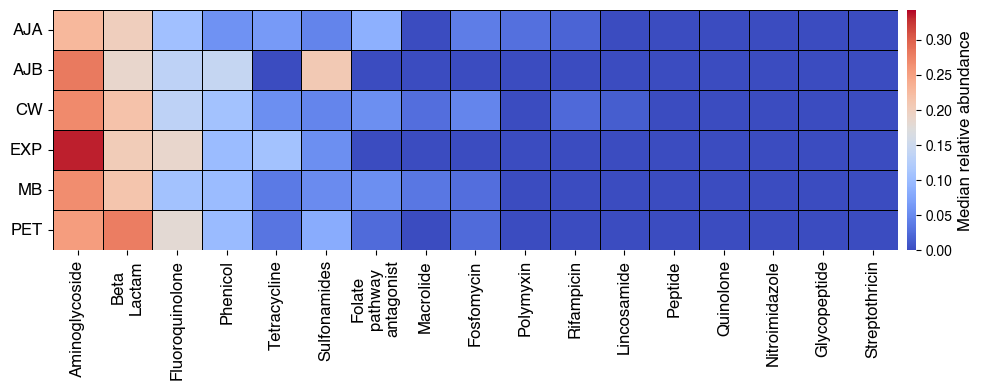

In [59]:
fig, ax = plt.subplots(figsize=(10, 4))

hm = sns.heatmap( group_medians, cmap="coolwarm", vmin=0, vmax=group_means.max().max(), linewidths=0.5, linecolor="black", cbar_kws={"label": "Median relative abundance","orientation": "vertical","pad": 0.01, "fraction": 0.035,"aspect": 25}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")

xlabs = [label.get_text().replace(" ", "\n") for label in ax.get_xticklabels()]

ax.set_xticklabels( xlabs, rotation=90, ha="center",  fontsize=12)
ax.set_yticklabels( ax.get_yticklabels(), rotation=0, fontsize=1)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.ax.yaxis.label.set_size(12)
plt.tight_layout()


plt.show()

In [60]:
counts = (MT.groupby(["sample", "Class"]).size().unstack(fill_value=0))

In [61]:
total_counts = counts.sum(axis=0)
top5 = total_counts.sort_values(ascending=False).head(5)
print(top5)

Class
Aminoglycoside     277
Beta Lactam        264
Fluoroquinolone    138
Phenicol            99
Tetracycline        78
dtype: int64


In [62]:
classdf=pd.DataFrame(total_counts).reset_index().rename(columns={0:"n"})
classdf[0:2]

,Class,n
0,Aminoglycoside,277
1,Beta Lactam,264


In [63]:
counts_long = (counts.reset_index().melt(id_vars='sample', var_name='antibiotic_class', value_name='count'))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AJB vs. EXP: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.578e-03 U_stat=1.500e+00
AJB vs. MBD: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.944e-03 U_stat=7.000e+00


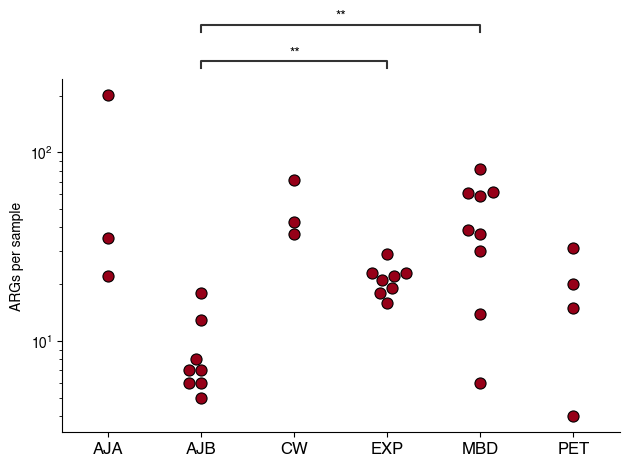

In [64]:
counts = (MT.groupby(['sample', 'canals']).size().reset_index(name='n'))

fig, ax = plt.subplots()

sns.swarmplot( data=counts, x='canals', y='n',  size=8,color="#960018",edgecolor='black',linewidth=0.8,ax=ax)

canals = counts['canals'].unique()
pairs = [(canals[i], canals[j]) for i in range(len(canals)) for j in range(i+1, len(canals))]

annotator = Annotator( ax, pairs, data=counts, x='canals',y='n')
plt.yscale('log')

annotator.configure(test='Mann-Whitney', text_format='star',loc='outside', comparisons_correction='fdr_bh',hide_non_significant=True)

annotator.apply_and_annotate()
sns.despine(top=True, right=True)
plt.xticks(size=12)
plt.xlabel('')
plt.ylabel('ARGs per sample')
plt.tight_layout()


plt.show()

In [65]:
MT["canals"]=[x[0:3] if "CW" not in x else x[0:2] for x in MT["sample"]]
MT["canals"]=MT["canals"].str.replace("MBM", "MBD").str.replace("MBU", "MBD")

In [66]:
canaldf=MT.groupby("canals").size().reset_index(name="n").sort_values("n", ascending=False)

In [67]:
canaldf

,canals,n
4,MBD,390
0,AJA,258
3,EXP,171
2,CW,151
1,AJB,70
5,PET,70


In [69]:
canaldf["n"].sum()

1110

In [70]:
counts = (MT.groupby(['sample', 'canals']).size().reset_index(name='n'))
print(counts.head())

     sample canals    n
0     AJA1A    AJA  201
1     AJA2A    AJA   35
2     AJA3A    AJA   22
3  AJBDWS1C    AJB    5
4  AJBDWS2C    AJB   18


In [ ]:
groups = [g['n'].values for _, g in counts.groupby('canals')]
stat, p = kruskal(*groups)
print(stat, p)

In [72]:
## Ntc
rdf=pd.read_csv("total_reads.txt", header=None, sep="\t")
rdf=rdf[rdf[1]=="R1.fastq.gz"]
rdf["map"]=rdf[0].str.replace("_", "")
rpm_arg=[]
for f in glob.glob("*.mapstat"):
    if "NE" not in f and  "NTC" not in f: 
        df = pd.read_csv(f, sep="\t", skiprows=6)
        df["# refSequence"]=df["# refSequence"].str.replace("_v1.0.1", "")
        df["L"]=df["# refSequence"].map(length_dict)
        t=rdf[rdf["map"]==n][2].values[0]
        df['RPKM'] =(1e9 * df['readCount']) / (t * df['L'])
        df["sample"]=re.sub("AACMFLCHV1cleaned.mapstat", "", f)
        rpm_arg.append(df)

# # print(np.min(rpm_arg))
# # print(np.max(rpm_arg))
# # print(np.median(rpm_arg))

rpmdf = pd.concat(rpm_arg)
rpmdf["canals"]=[x[0:3] if "CW" not in x else x[0:2] for x in rpmdf["sample"]]
rpmdf["canals"]=rpmdf["canals"].str.replace("MBM", "MBD").str.replace("MBU", "MBD")

In [73]:
temp_d=dict(zip(MT["#Template"], MT["Class"]))

In [74]:
rpmdf["class"]=rpmdf["# refSequence"].map(temp_d)

In [75]:
byclass=rpmdf[~rpmdf["class"].isna()]

In [76]:
byclass=byclass[["RPKM", "class"]]

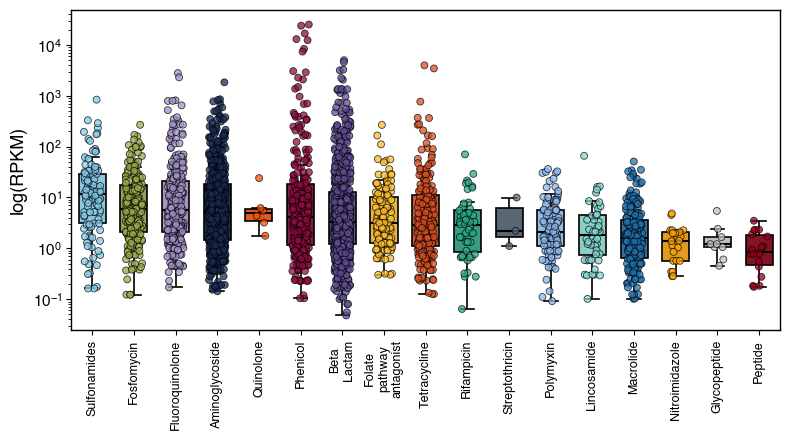

In [77]:
plot_df = byclass.dropna(subset=["RPKM", "class"]).copy()
plot_df = plot_df[plot_df["RPKM"] > 0]

class_order = (plot_df.groupby("class")["RPKM"].median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.boxplot(data=plot_df, x="class", y="RPKM", order=class_order,palette=col_dict,showfliers=False,width=0.65,linewidth=1.2, boxprops={"edgecolor": "black"},medianprops={"color": "black", "linewidth": 1.5}, whiskerprops={"color": "black", "linewidth": 1.2},capprops={"color": "black", "linewidth": 1.2},ax=ax)

sns.stripplot( data=plot_df, x="class",y="RPKM", order=class_order, palette=col_dict,size=5, edgecolor="black", linewidth=0.6, alpha=0.75, jitter=0.2, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("log(RPKM)", fontsize=13)
ax.set_yscale("log")

ax.set_xticklabels([label.get_text().replace(" ", "\n") for label in ax.get_xticklabels()])

ax.tick_params(axis="x", labelsize=9, colors="black", labelrotation=90)
ax.tick_params(axis="y", labelsize=11, colors="black")

for label in ax.get_xticklabels():
    label.set_ha("center")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.grid(False)

plt.tight_layout()


plt.show()

In [79]:
rpmdf=rpmdf[rpmdf["# refSequence"].isin(MT["#Template"].to_list())]

In [80]:
rpmdf["fragmentCount"].sum()

1200114

In [81]:
rpmdf["RPKM"].median()

3.577956400499274

In [ ]:
test_df = rpmdf[["canals", "RPKM"]].dropna().copy()
groups = [ group["RPKM"].values
    for _, group in test_df.groupby("canals")]
stat, pval = kruskal(*groups)
summ = test_df.groupby("canals")["RPKM"].agg(["count", "median", "mean", "std", "min", "max"]).reset_index()

summ

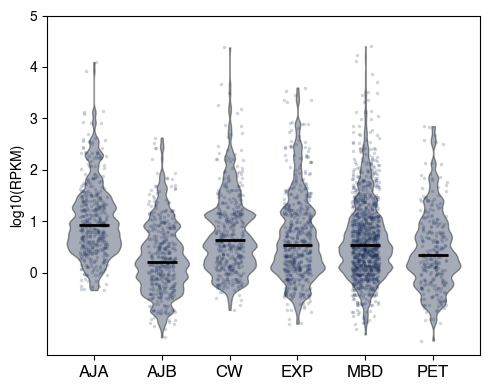

In [83]:
rpmdf = rpmdf.copy()
rpmdf['log_RPKM'] = np.log10(rpmdf['RPKM'] + 1e-6)
order = sorted(rpmdf['canals'].dropna().unique())
n = len(order)
fig_width = max(8, n * 1.2)
fig, ax = plt.subplots(figsize=(5, 4))

plt.rcParams['font.family'] = 'Helvetica'


sns.violinplot(data=rpmdf,x='canals', y='log_RPKM',order=order,inner=None, cut=0,scale='width', bw_adjust=0.3, color="#182b55", linewidth=1,alpha=1, ax=ax)


for violin in ax.collections:
    violin.set_alpha(0.4)           
    violin.set_edgecolor('black')
    violin.set_linewidth(1)

sns.stripplot( data=rpmdf, x='canals', y='log_RPKM', order=order,color='#182b55',size=2.5,jitter=0.2,alpha=0.2, ax=ax)
medians = rpmdf.groupby('canals')['log_RPKM'].median().reindex(order)

for i, median in enumerate(medians):
    ax.hlines( y=median, xmin=i - 0.22, xmax=i + 0.22, color='black',linewidth=2, zorder=5)

plt.xticks(size=12)
plt.xlabel('')
plt.ylabel('log10(RPKM)')

ax.set_yticks([t for t in ax.get_yticks() if t > -1e-9])
plt.tight_layout()


plt.show()

In [85]:
sample_rpkm = rpmdf.dropna(subset=["sample", "canals", "RPKM"]).groupby(["sample", "canals"], as_index=False).agg(total_RPKM=("RPKM", "sum"),median_RPKM=("RPKM", "median"),mean_RPKM=("RPKM", "mean"),n_ARGs=("# refSequence", "nunique"))

In [86]:
pop_catchment = { "EXP": 1554771,
    "CW": 1607903,
    "AJA": 926846,
    "MBD": 1554572,
    "PET": 533714,
    "AJB": 527665}

area_sqkm = {"EXP": 56.059150,
    "CW": 58.334600,
    "AJA": 19.292530,
    "MBD": 56.051600,
    "PET": 34.747900,
    "AJB": 34.477040}

pop_density = {canal: pop_catchment[canal] / area_sqkm[canal] for canal in pop_catchment}
sample_rpkm["population_density"] = sample_rpkm["canals"].map(pop_density)

In [100]:
from statsmodels.stats.multitest import multipletests

res = pd.DataFrame({
    "metric": ["total_RPKM", "median_RPKM", "mean_RPKM", "n_ARGs"],
    "spearman_rho": [0.652, 0.429, 0.619, 0.295],
    "p_value": [2.245e-05, 0.01018, 7.402e-05, 0.08529]})

res["p_adj_BH"] = multipletests( res["p_value"],method="fdr_bh")[1]

res

,metric,spearman_rho,p_value,p_adj_BH
0,total_RPKM,0.652,0.000022,0.000090
1,median_RPKM,0.429,0.010180,0.013573
2,mean_RPKM,0.619,0.000074,0.000148
3,n_ARGs,0.295,0.085290,0.085290


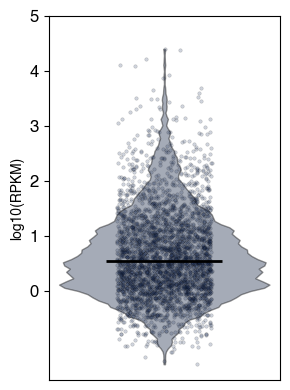

In [88]:
rpmdf["log_RPKM"] = np.log10(rpmdf["RPKM"] + 1e-6)
rpmdf["category"] = "ARGs"

fig, ax = plt.subplots(figsize=(3, 4))

sns.violinplot( data=rpmdf,x="category",y="log_RPKM",inner=None,cut=0,scale="width",bw_adjust=0.3,color="#182b55", linewidth=1,alpha=1, ax=ax)

for violin in ax.collections:
    violin.set_alpha(0.4)
    violin.set_edgecolor("black")
    violin.set_linewidth(1)

sns.stripplot(data=rpmdf, x="category",y="log_RPKM",color="#182b55",size=2.5,jitter=0.18,alpha=0.2, edgecolor="black", linewidth=0.4, ax=ax)

median = rpmdf["log_RPKM"].median()

ax.hlines(y=median, xmin=-0.22, xmax=0.22, color="black", linewidth=2, zorder=5)

ax.set_xlabel("")
ax.set_ylabel("log10(RPKM)")
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_yticks([t for t in ax.get_yticks() if t > -1e-9])
plt.yticks(size=12)
plt.tight_layout()

plt.show()

In [89]:
div_df = rpmdf[["sample", "canals", "# refSequence", "RPKM"]].dropna().copy()
div_df = div_df[div_df["RPKM"] > 0]
arg_abund = (div_df.groupby(["sample", "canals", "# refSequence"], as_index=False)["RPKM"].sum())
arg_abund["p"] = (arg_abund["RPKM"] / arg_abund.groupby("sample")["RPKM"].transform("sum"))
shannon_df = (arg_abund.assign(plogp=lambda x: x["p"] * np.log(x["p"])).groupby(["sample", "canals"], as_index=False).agg(shannon_diversity=("plogp", lambda x: -x.sum()),n_ARGs=("# refSequence", "nunique"),total_RPKM=("RPKM", "sum")))
shannon_df

,sample,canals,shannon_diversity,n_ARGs,total_RPKM
0,AJA1A,AJA,4.211241,233,14107.273529
1,AJA2A,AJA,1.416037,120,11673.170768
2,AJA3A,AJA,0.787602,63,15015.954882
3,AJBDWS1C,AJB,2.878209,39,220.427726
4,AJBDWS2C,AJB,2.828124,46,621.318472
5,AJBDWS3C,AJB,2.564692,43,252.972876
6,AJBMDS2B,AJB,2.451749,35,178.126144
7,AJBMDS3B,AJB,1.717708,50,406.103175
8,AJBUPS1A,AJB,1.787835,48,561.747195
9,AJBUPS2A,AJB,2.545560,65,636.528469


In [90]:
shannon_summary = (shannon_df.groupby("canals")["shannon_diversity"].agg(["count", "median", "mean", "std", "min", "max"]).reset_index())

shannon_summary

,canals,count,median,mean,std,min,max
0,AJA,3,1.416037,2.138293,1.822517,0.787602,4.211241
1,AJB,8,2.498654,2.331266,0.469004,1.717708,2.878209
2,CW,3,1.816671,2.117787,0.666617,1.654850,2.881839
3,EXP,8,2.193821,2.236918,0.496334,1.653059,3.192583
4,MBD,9,1.906523,1.974756,0.618670,1.279947,3.050886
5,PET,4,2.065316,2.203988,0.404611,1.891220,2.794101


In [ ]:
s = [group["shannon_diversity"].valuesfor _, group in shannon_df.groupby("canals")]

stat, pval = kruskal(*groups)


In [92]:
from scipy.stats import mannwhitneyu
pr = []

for c1, c2 in combinations(shannon_df["canals"].dropna().unique(), 2):
    x = shannon_df.loc[shannon_df["canals"] == c1, "shannon_diversity"].dropna()
    y = shannon_df.loc[shannon_df["canals"] == c2, "shannon_diversity"].dropna()

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    pr.append({ "canal_1": c1, "canal_2": c2, "n_1": len(x), "n_2": len(y),"median_1": x.median(), "median_2": y.median(), "difference_median": x.median() - y.median(), "U_statistic": stat,"p_value": p})

p_df = pd.DataFrame(pr)
p_df["p_adj_BH"] = multipletests( p_df["p_value"],  method="fdr_bh")[1]
p_df = p_df.sort_values("p_adj_BH")
p_df.sort_values("p_value")

,canal_1,canal_2,n_1,n_2,median_1,median_2,difference_median,U_statistic,p_value,p_adj_BH
7,AJB,MBD,8,9,2.498654,1.906523,0.592131,47.0,0.321267,0.925325
14,MBD,PET,9,4,1.906523,2.065316,-0.158793,12.0,0.413986,0.925325
12,EXP,MBD,8,9,2.193821,1.906523,0.287298,44.0,0.480708,0.925325
0,AJA,AJB,3,8,1.416037,2.498654,-1.082618,8.0,0.496970,0.925325
2,AJA,EXP,3,8,1.416037,2.193821,-0.777785,8.0,0.496970,0.925325
4,AJA,PET,3,4,1.416037,2.065316,-0.649280,4.0,0.628571,0.925325
11,CW,PET,3,4,1.816671,2.065316,-0.248646,4.0,0.628571,0.925325
9,CW,EXP,3,8,1.816671,2.193821,-0.377150,9.0,0.630303,0.925325
6,AJB,EXP,8,8,2.498654,2.193821,0.304833,37.0,0.645377,0.925325
1,AJA,CW,3,3,1.416037,1.816671,-0.400634,3.0,0.700000,0.925325


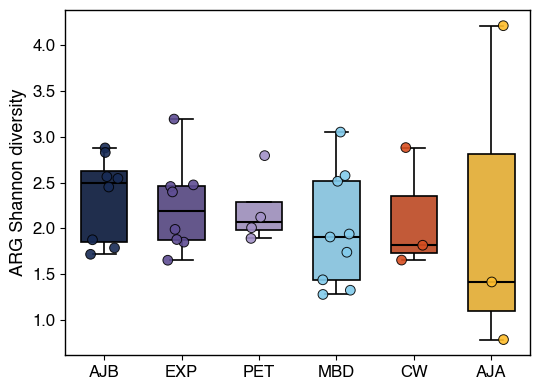

In [93]:

canal_cols = ["#182b55", "#5f4e94","#a291c7", "#82cbec", "#d94f21", "#febd2b", "#9aab4b"]
canal_order = (shannon_df.groupby("canals")["shannon_diversity"].median().sort_values(ascending=False).index)
palette = dict(zip(canal_order, canal_cols[:len(canal_order)]))
fig, ax = plt.subplots(figsize=(5.5, 4))

sns.boxplot( data=shannon_df, x="canals", y="shannon_diversity", order=canal_order, palette=palette,width=0.6,showfliers=False,linewidth=1.2,boxprops={"edgecolor": "black"},medianprops={"color": "black", "linewidth": 1.5}, whiskerprops={"color": "black", "linewidth": 1.2},capprops={"color": "black", "linewidth": 1.2}, ax=ax)

sns.stripplot( data=shannon_df, x="canals", y="shannon_diversity", order=canal_order,palette=palette,size=7, edgecolor="black",linewidth=0.7,alpha=0.9,jitter=0.18, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("ARG Shannon diversity", fontsize=13)

ax.tick_params(axis="x", labelsize=12, colors="black")
ax.tick_params(axis="y", labelsize=12, colors="black")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.grid(False)
plt.tight_layout()

plt.show()